In [1]:
from app_recouple import *
import pandas as pd

c:\Users\yemi\Downloads\full-disk-deployment\menv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
db = pd.read_csv('predictions.txt')
ars = pd.read_csv('ars.csv')
flare_actual = pd.read_csv('Flares.csv')

In [3]:
def get_flare(date_param, df):
    """
    Checks if there are any records in the dataframe where isFlare is True
    and largestEventDate is within the date_param and 24 hours after.

    Parameters:
    date_param (datetime): The date to check against.
    df (DataFrame): The dataframe containing the records.

    Returns:
    DataFrame: A dataframe containing the matching records.
    """
    # Convert the date_param to datetime if it is not already
    if not isinstance(date_param, pd.Timestamp):
        date_param = pd.to_datetime(date_param)

    # Define the end date (24 hours after date_param)
    end_date = date_param + timedelta(hours=24)
    end_date = pd.to_datetime(end_date).tz_localize(None)
    date_param = pd.to_datetime(date_param).tz_localize(None)

    # print(date_param.values[0])
    # print(end_date.values[0])
    # print(type(end_date.values[0]))

    # Filter the dataframe
    result = df[(df['Is_Flare'] == True) & 
                (pd.to_datetime(df['Largest Event Date']) >= pd.to_datetime(date_param)) & 
                (pd.to_datetime(df['Largest Event Date']) < pd.to_datetime(end_date))]


    # result = df[(df['Is_Flare'] == True) & 
    #             (df['Largest Event Date'] >= date_param) & 
    #             (df['Largest Event Date'] < end_date)]

    return result

In [4]:
# Find the row with the specific timestamp in the DataFrame
def get_metrics(row,plage,events):
    try:
        guidedgradcam = retrieve_npy(row['local_request_date'],root='guidedgradcam')
        original = retrieve_npy(row['local_request_date'],root='original')
        ar_names,ar_lat,ar_lon = retrieve_ar(row['local_request_date'],
        plage=plage ,
        events=events
        )

        actual_pred = get_flare(row['obs_date'],flare_actual)
        # if actual_pred.shape[0] >= 1:
        #     actual_pred = 1
        # else:
        #     actual_pred = 0

        pix_list = [post_hoc_explanation.convert_to_pix(float(x[1]),float(x[0])) for x in zip(ar_lat,ar_lon)]
        flares = [item for item in list(zip(ar_names,pix_list))]

        # Analyze attention map
        bounding_hulls_img, distances_df, score, ratio = post_hoc_explanation.explain(guidedgradcam, flares, -20, 20, 5, 40, 30, 50, 2, 10, numpy=True)
    except Exception as e:
        return None, None, None, actual_pred.shape[0]
    return  distances_df.to_dict(orient='list'), score, ratio,actual_pred.shape[0]

In [5]:
db[['distances_df_all', 'score_all', 'ratio_all','actual']] = db.apply(
    lambda row: pd.Series(get_metrics(row, True, True)), axis=1
    
)

c:\Users\yemi\Downloads\full-disk-deployment\post_hoc_explanation.py:56: RuntimeWarning: invalid value encountered in divide
  img = (img - img.min()) / (img.max() - img.min())
c:\Users\yemi\Downloads\full-disk-deployment\post_hoc_explanation.py:57: RuntimeWarning: invalid value encountered in cast
  img  = (img * 255).astype(np.uint8)
c:\Users\yemi\Downloads\full-disk-deployment\menv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\yemi\Downloads\full-disk-deployment\menv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\yemi\Downloads\full-disk-deployment\menv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\yemi\Downloads\full-disk-deployment\menv\Lib\site-packages\numpy\_core\_methods.py

In [6]:
# db.to_csv('processed_alexnet.csv',index=False)

In [12]:
# import pandas as pd

# Assuming df is your DataFrame
# Step 1: Convert local_request_date to datetime format
db['local_request_date'] = pd.to_datetime(db['local_request_date'])
# print(db.shape)

# Step 2: Filter out rows where ratio is NaN
df_filtered = db.dropna(subset=['score_all']).reset_index(drop=True)
# print(df_filtered.shape)

# Step 3: Extract year, month, and day
df_filtered['year'] = df_filtered['local_request_date'].dt.year
df_filtered['month'] = df_filtered['local_request_date'].dt.month
df_filtered['day'] = df_filtered['local_request_date'].dt.day

# Step 4: Group by year and month, then count the number of unique days
result = df_filtered.groupby(['year', 'month'])['day'].nunique().reset_index()

# Rename the 'day' column to 'unique_days' for clarity
result = result.rename(columns={'day': 'unique_days'})

# print(result)


In [13]:
df_filtered['actual_pred']=df_filtered['actual'].apply(lambda x: 1 if x >= 1.0 else 0)
df_filtered['actual'].value_counts()
df_filtered['score_all_bound'] = df_filtered['score_all']/400
# df_filtered[(df_filtered.actual_pred != 0) & (df_filtered.actual <1)][['actual_pred','actual']]

In [14]:
# import pandas as pd

# Assuming df is your DataFrame with 'scored_probabilities' and 'actual' fields
# Define the threshold
threshold = 0.5

# Step 1: Get predicted labels based on the threshold
df_filtered['predicted'] = df_filtered['flare_probability'].apply(lambda x: 1 if x >= threshold else 0)

# Step 2: Classify each record as FP, TP, FN, or TN
def classify(row):
    if row['predicted'] == 1 and row['actual_pred'] == 1:
        return 'TP'
    elif row['predicted'] == 1 and row['actual_pred'] == 0:
        return 'FP'
    elif row['predicted'] == 0 and row['actual_pred'] == 1:
        return 'FN'
    elif row['predicted'] == 0 and row['actual_pred'] == 0:
        return 'TN'

df_filtered['classification'] = df_filtered.apply(classify, axis=1)

# Display the DataFrame with the new column
print(df_filtered['classification'].value_counts())


classification
TN    4412
FP     406
TP     316
FN     173
Name: count, dtype: int64


In [10]:
# Group by classification and calculate descriptive statistics for the ratio field
stats = df_filtered.groupby('classification')['ratio_all'].describe()
stats

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
FN,173.0,0.505087,0.320827,0.0,0.33,0.5,0.75,1.0
FP,406.0,0.514778,0.295499,0.0,0.33,0.5,0.75,1.0
TN,4412.0,0.543719,0.362010,0.0,0.25,0.5,1.00,1.0
TP,316.0,0.583070,0.301381,0.0,0.33,0.5,0.83,1.0


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a box plot to visualize the ratio field for each classification category
plt.figure(figsize=(10, 6))
sns.boxplot(x='classification', y='score_all', data=df_filtered)
plt.title('Distribution of Ratio Field by Classification Category')
plt.xlabel('Classification')
plt.ylabel('Ratio')
plt.show()


C:\Users\yemi\AppData\Local\Temp\ipykernel_1104\347541184.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [18]:
import matplotlib.pyplot as plt

# Create box plots
plt.figure(figsize=(10, 6))
df_filtered.boxplot(column='ratio_all', by='classification', grid=False)
plt.title('Distribution of Ratio Field by Classification Category')
plt.suptitle('')  # Suppress the default title
plt.xlabel('Classification')
plt.ylabel('Ratio')
plt.show()


C:\Users\yemi\AppData\Local\Temp\ipykernel_1104\3031245626.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


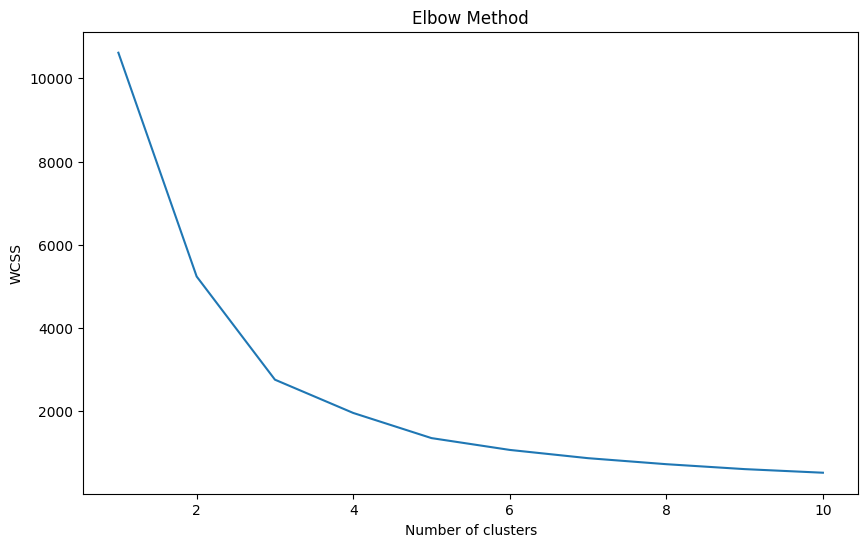

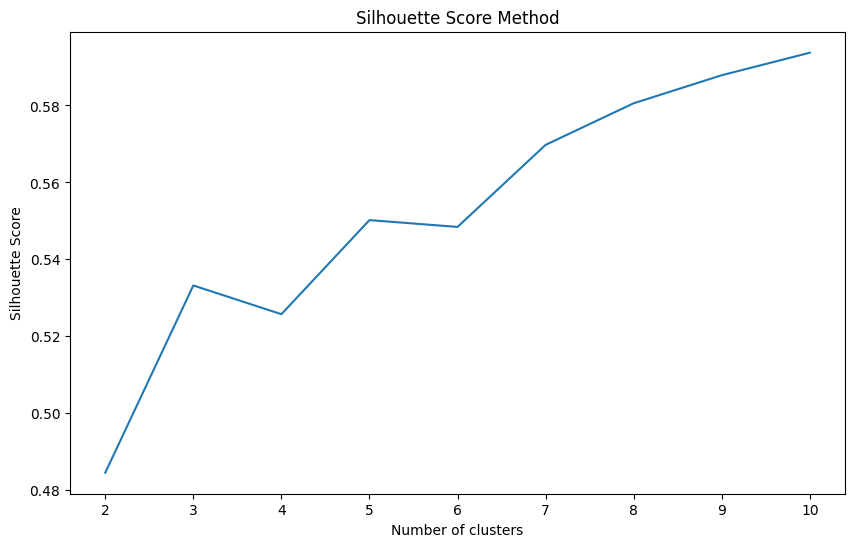

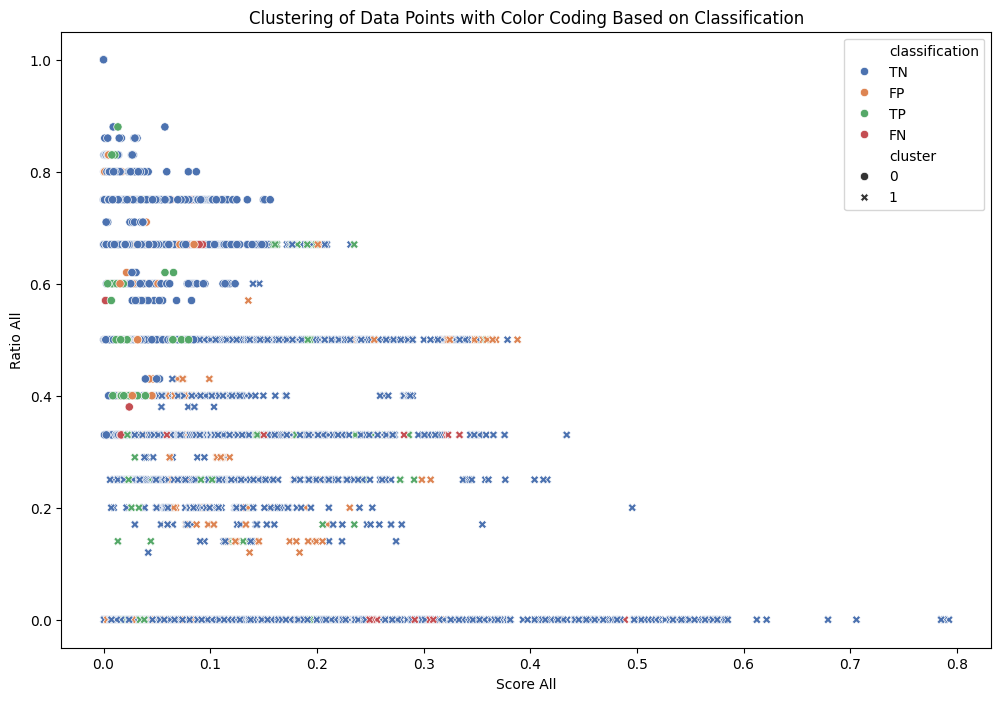

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Assuming df is your DataFrame with 'score_all', 'ratio_all', and 'classification' fields
data = df_filtered[['score_all_bound', 'ratio_all']]

# Handle missing values if any
data = data.dropna()

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Using the Elbow Method to determine the optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Using Silhouette Score to determine the optimal number of clusters
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(data_scaled)
    score = silhouette_score(data_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores)
plt.title('Silhouette Score Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

# Performing K-Means clustering with the chosen number of clusters (let's assume 4 for this example)
kmeans = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10, random_state=42)
df_filtered['cluster'] = kmeans.fit_predict(data_scaled)

# Visualizing the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='score_all_bound', y='ratio_all', hue='classification', style='cluster', palette='deep', data=df_filtered)
plt.title('Clustering of Data Points with Color Coding Based on Classification')
plt.xlabel('Score All')
plt.ylabel('Ratio All')
plt.legend(loc='best')
plt.show()


In [ ]:
!pip install lazypredict 

^C


In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

# Load the Iris dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit LazyClassifier on the training data and evaluate on the testing data
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# Display the performance of different models
print(models)


ModuleNotFoundError: No module named 'lazypredict'